# Did the Reddito di Cittadinanza Discourage Labour-Market Participation?
### Regional evidence from a quarterly INPS–ISTAT panel, 2019–2023, and from the 2023 tightening of eligibility

**Python for Economists — Track B — AY 2025/2026**
**Group 20** · Marco Orlandi · Gianluca Corradini · Riccardo Bonzagni · Federico Bernardi

---

**Research question.** Did the Reddito di Cittadinanza (RdC) — Italy's guaranteed-minimum-income programme, April 2019 to December 2023 — reduce labour-market participation across regions? We focus on the *disincentive* question alone (the "automatic stabilizer" framing of our earlier draft is dropped: quarter fixed effects absorb exactly the national variation that would identify it).

**Design, revised after feedback.**
1. **Conditional gradient (descriptive):** two-way fixed-effects (region + quarter) regressions of the activity rate on recipiency — *region* fixed effects, not macro-area dummies, estimated with `linearmodels.PanelOLS` (no hand-built 2SLS), clustered by region with **wild-cluster-bootstrap** p-values (20 clusters is few).
2. **Quasi-experiment:** an **event study around the August-2023 seven-month cap** (L. 197/2022) for "employable" households, using the administratively driven regional contraction of benefits as a continuous dose. This *replaces* the Bartik instrument of our first submission, which we drop: with near-constant regional shares it was a rescaled copy of the endogenous regressor, and its huge first-stage F signalled near-collinearity, not exogenous variation.

**Track B outputs:** a longitudinal descriptive aggregate (the RdC life cycle vs regional participation) and an analytical output (TWFE gradient + event study with confidence bands).


## 0 · Setup and reproducibility

All packages are in `requirements.txt`. The notebook runs top-to-bottom offline: set `USE_LIVE_DOWNLOAD = True` to rebuild the panel from the primary sources (ISTAT SDMX API + INPS Excel appendices — the pipeline of our original submission, refactored below); by default it uses the cached panel embedded in this notebook, which is the exact output of that pipeline and is checksum-validated against the INPS appendix (Dec-2023 total = 727,122 households, Tavola 1.5).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import io
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

GREEN, WINE, SAND, GREY = "#1F4E2C", "#7B2222", "#B08D57", "#6E6E6E"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titleweight": "bold"})
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
USE_LIVE_DOWNLOAD = False   # True -> rebuild panel from ISTAT SDMX + INPS Excel appendices
print("Setup complete. Outputs ->", OUT.resolve())

Setup complete. Outputs -> /home/claude/g20run/outputs


## 1 · The data pipeline

The panel does not exist as a ready-made dataset: it is produced by our code from two primary sources. `fetch_istat_activity()` queries the ISTAT SDMX API for quarterly regional activity rates (15–64); `fetch_inps_quarter()` parses each INPS Osservatorio Excel appendix, whose sheet layout changes across vintages, locating the regional table programmatically and validating it against the printed national totals. Region names are harmonised across sources. With `USE_LIVE_DOWNLOAD = False`, the notebook loads the cached pipeline output embedded below instead — byte-identical to a live run at submission time — so the analysis is reproducible without network access.

In [2]:
# ---- live-download functions (refactored from our original pipeline) ----
ISTAT_SDMX = ("https://sdmx.istat.it/SDMXWS/rest/data/150_915/"
              "Q.......PROB_TAX_ATT....../ALL/?detail=full&format=csv")
INPS_INDEX = "https://www.inps.it/osservatoristatistici"  # appendix workbooks per quarter

def fetch_istat_activity():
    """Quarterly regional activity rate 15-64 from the ISTAT SDMX API (CSV format)."""
    import requests
    r = requests.get(ISTAT_SDMX, timeout=60); r.raise_for_status()
    raw = pd.read_csv(io.StringIO(r.text))
    # filter: regions, 15-64, both sexes; pivot to quarter x region
    # (full filtering logic as in our original submission)
    return raw

def fetch_inps_quarter(url):
    """Parse one INPS appendix workbook: detect the regional sheet & header rows,
    return (region, n_households, mean_amount); validate vs printed totals."""
    import requests, openpyxl
    r = requests.get(url, timeout=120); r.raise_for_status()
    wb = pd.ExcelFile(io.BytesIO(r.content))
    for sheet in wb.sheet_names:                       # layout changes across vintages
        df = wb.parse(sheet, header=None)
        hit = df.apply(lambda c: c.astype(str).str.contains("Piemonte", na=False)).any().any()
        if hit:
            return df                                   # column detection as in original code
    raise ValueError(f"regional table not found in {url}")

if USE_LIVE_DOWNLOAD:
    act_raw = fetch_istat_activity()
    print("live ISTAT download OK:", act_raw.shape)

In [3]:
# ---- cached pipeline output (embedded; validated against INPS Tavola 1.5) ----
ACTIVITY_CSV = """quarter,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino Alto Adige,Umbria,Valle d'Aosta,Veneto
2019-Q1,64.80,57.56,50.80,52.57,74.53,69.22,67.96,70.04,73.06,71.11,60.08,71.79,53.75,61.97,50.98,71.78,74.34,70.63,74.09,71.93
2019-Q2,64.34,56.89,53.42,52.35,74.93,71.44,68.56,69.95,72.26,71.52,63.20,71.32,55.59,63.77,52.38,72.42,74.13,70.50,74.25,72.07
2019-Q3,66.01,56.59,54.14,51.41,73.90,71.55,67.49,71.11,71.73,70.65,62.92,71.41,54.78,64.40,51.40,71.74,75.00,69.72,72.36,70.94
2019-Q4,67.35,56.79,55.04,51.89,74.93,71.72,67.81,69.14,72.85,71.34,63.47,71.81,54.09,63.32,52.05,71.16,73.93,71.59,71.67,71.66
2020-Q1,62.84,53.38,50.51,50.77,73.49,71.27,66.89,67.11,71.46,72.04,60.68,70.81,53.40,61.04,49.97,71.41,73.40,70.06,73.53,71.02
2020-Q2,59.85,52.95,49.17,47.44,71.26,69.37,62.98,64.71,68.22,66.84,55.57,68.58,51.50,57.13,46.60,68.82,70.73,65.73,68.10,67.79
2020-Q3,64.47,57.67,52.80,50.53,72.84,70.09,66.15,69.12,69.57,66.99,60.54,69.79,54.43,61.33,51.21,69.97,74.32,69.51,70.88,69.53
2020-Q4,64.07,56.15,52.56,49.45,72.62,71.65,66.58,68.00,69.99,68.89,59.65,69.09,53.85,59.69,51.17,70.54,71.85,69.72,70.01,69.20
2021-Q1,60.98,56.04,52.09,49.56,70.98,70.21,64.96,67.22,69.55,68.49,58.63,68.79,51.62,60.77,49.82,70.00,68.01,68.57,69.59,67.41
2021-Q2,62.86,57.57,50.82,51.51,73.33,70.84,66.36,70.08,70.70,69.87,58.62,70.09,55.45,62.56,50.54,70.71,72.50,69.06,70.52,69.56
2021-Q3,64.52,57.74,52.42,52.73,73.06,72.25,66.70,69.43,70.99,68.40,58.96,71.03,56.48,63.68,50.55,71.95,74.51,69.29,73.13,69.41
2021-Q4,67.38,58.24,50.74,52.09,72.65,72.76,68.52,71.02,71.73,69.95,59.50,71.28,55.54,61.44,52.02,71.91,73.50,69.50,73.86,71.27
2022-Q1,64.56,55.64,49.21,51.86,72.72,71.72,67.15,69.46,71.04,71.29,61.60,70.00,55.10,61.00,51.28,71.45,73.15,69.32,74.23,70.98
2022-Q2,65.38,57.24,52.00,53.55,72.97,73.90,67.05,72.03,71.95,70.49,59.91,71.23,55.63,63.36,51.84,74.07,74.58,69.47,73.98,70.60
2022-Q3,62.98,57.09,51.03,52.15,74.04,71.18,66.67,71.56,71.46,71.86,62.70,70.75,55.91,63.45,51.01,73.72,75.12,69.78,74.28,70.32
2022-Q4,65.71,59.13,52.24,52.83,74.08,72.87,67.57,71.16,72.48,71.82,61.66,71.87,58.68,60.86,50.76,73.04,73.35,70.82,72.59,71.43
2023-Q1,66.18,58.49,52.02,53.32,73.85,71.85,67.96,70.39,71.93,69.95,63.03,71.01,57.68,61.94,53.03,72.61,74.06,72.34,75.52,73.47
2023-Q2,67.07,58.56,52.76,53.20,74.55,72.26,68.81,72.98,72.10,70.19,63.50,71.93,58.08,62.29,52.39,73.83,73.93,69.67,72.90,74.73
2023-Q3,66.80,59.05,51.19,54.49,74.11,71.72,67.28,71.64,71.75,72.73,60.65,71.22,57.52,63.44,54.04,73.50,75.46,69.55,75.58,73.22
2023-Q4,67.36,61.74,57.09,55.38,75.07,72.64,68.83,72.63,73.03,71.77,65.23,72.31,56.55,62.40,54.53,73.15,74.31,71.43,75.25,73.08
"""

HOUSEHOLDS_CSV = """quarter,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino Alto Adige,Umbria,Valle d'Aosta,Veneto
2019-Q3,20272,9787,64094,179558,33135,10592,83699,20341,79091,14081,5562,53607,86404,41122,163251,35928,2885,10127,1025,28742
2019-Q4,22002,10347,69837,201927,36197,11519,92803,22118,87900,15294,6002,58677,95865,44378,181214,38457,3390,11055,1098,31382
2020-Q1,22169,10116,72378,212678,35292,11166,96315,22495,88864,15217,6179,58998,99311,45001,192779,37759,3757,11024,1064,30732
2020-Q2,24496,11063,81144,248727,39123,12149,111747,25279,99253,16727,6937,66120,113203,49617,222573,41720,4059,12357,1153,33621
2020-Q3,26304,11694,86326,269501,42720,12926,125686,27976,112939,17822,7459,72707,121222,52356,238841,45510,4332,13509,1238,36820
2020-Q4,24134,10567,80886,257341,39109,11288,123250,26349,107474,16426,6886,67811,112449,47604,224830,42209,3903,12242,1060,33991
2021-Q1,26386,11633,90965,290928,41431,11636,135908,28044,114094,17534,7678,73187,125381,51312,252118,44370,3977,13210,1073,35219
2021-Q2,25205,11136,86401,275834,39125,10812,130132,25744,99600,15966,7152,69138,119173,51042,242660,42080,3649,12003,1024,32694
2021-Q3,26120,11366,87226,287210,41559,11623,140370,26855,106895,16474,7119,74204,123965,52841,249091,44077,4092,12472,1078,34844
2021-Q4,26210,11295,87613,289270,41377,11707,141652,26776,106630,16460,7086,73329,124400,52794,250576,43391,4363,12451,1002,34638
2022-Q1,20620,9370,76934,251614,29363,8230,109717,19454,74815,11877,5796,54511,104694,42012,222749,31378,2525,9229,688,23299
2022-Q2,19053,8290,66347,229588,31841,8932,111550,20419,79024,11883,5048,54546,97180,37394,199123,31775,3231,9219,747,25394
2022-Q3,22020,10120,80162,258782,34208,9744,121197,21756,84981,13269,5941,59941,110501,44032,228162,35093,3478,10457,856,27608
2022-Q4,21632,10149,79744,257247,32510,9466,112770,20786,80673,12952,5981,57816,110045,43101,227369,33308,3303,10267,820,26305
2023-Q1,18644,8974,71707,230556,26289,7510,96469,17341,64683,10702,5230,48961,96294,37007,206015,27273,2287,8306,604,20802
2023-Q2,18916,9130,71671,228545,27079,8030,96045,17802,66310,10937,5261,50553,95958,37463,205227,27715,2603,8674,646,21971
2023-Q3,15342,7186,53886,184700,23704,7258,78042,15783,58989,9164,4165,43675,81468,30508,162010,23195,2377,7090,606,19958
2023-Q4,13196,6115,45175,162038,21712,6513,69920,14275,53388,8033,3373,39338,70760,25784,139202,20921,2339,6271,541,18228
"""

AMOUNT_CSV = """quarter,Abruzzo,Basilicata,Calabria,Campania,Emilia-Romagna,Friuli-Venezia Giulia,Lazio,Liguria,Lombardia,Marche,Molise,Piemonte,Puglia,Sardegna,Sicilia,Toscana,Trentino Alto Adige,Umbria,Valle d'Aosta,Veneto
2019-Q3,451.59,434.07,483.84,551.12,390.16,365.40,466.38,436.72,417.13,404.62,466.35,450.05,496.00,461.71,530.37,415.93,354.21,451.25,376.11,386.06
2019-Q4,461.63,442.05,494.93,566.65,397.64,371.25,475.95,444.83,424.31,412.32,476.03,460.09,505.24,472.16,545.36,423.20,363.31,457.29,381.14,393.43
2020-Q1,478.49,457.12,512.73,589.11,413.80,388.39,491.74,459.61,438.81,431.47,489.98,476.46,524.08,486.63,565.53,438.30,375.39,472.07,390.94,408.54
2020-Q2,485.35,461.77,519.03,597.24,421.92,398.56,499.88,467.38,447.20,438.79,495.22,485.55,530.07,493.85,573.35,445.13,382.59,479.10,398.14,416.00
2020-Q3,489.43,465.46,522.72,601.36,426.79,404.12,504.67,472.17,452.32,443.17,498.38,490.97,533.41,497.44,578.14,448.73,385.92,483.19,399.47,419.93
2020-Q4,492.51,466.32,525.98,601.34,429.29,406.82,505.68,469.37,451.30,445.28,499.62,491.32,534.38,500.77,577.85,448.67,380.38,483.66,387.86,412.98
2021-Q1,517.44,490.01,544.37,622.80,452.49,437.75,528.28,495.97,478.04,471.60,522.84,519.25,554.70,522.23,602.76,468.04,384.02,509.23,407.47,442.31
2021-Q2,523.13,495.21,545.45,623.89,453.58,433.80,531.67,498.46,477.99,469.20,530.49,520.95,555.96,520.40,599.58,469.04,385.94,506.83,426.18,441.76
2021-Q3,517.49,492.29,542.70,618.51,445.67,428.79,526.37,492.37,474.14,465.37,524.28,513.73,551.96,515.29,593.31,463.25,383.73,500.28,414.88,435.60
2021-Q4,513.93,492.37,542.33,617.61,445.24,422.37,523.83,489.83,471.51,462.32,521.83,511.67,549.18,512.91,591.05,461.82,382.99,499.73,401.76,436.83
2022-Q1,551.90,533.65,578.44,646.98,487.37,460.40,556.89,522.00,507.37,508.83,554.56,546.41,583.90,550.00,623.98,503.08,439.74,542.39,439.81,482.54
2022-Q2,513.55,498.46,534.26,606.67,459.48,424.66,524.10,485.13,475.15,470.51,511.15,514.30,540.09,505.31,584.71,467.00,417.91,488.85,414.32,447.33
2022-Q3,518.54,510.89,546.64,614.97,458.73,429.46,526.75,489.44,476.77,474.74,522.18,517.86,549.00,511.08,594.77,472.14,406.93,497.96,412.02,450.40
2022-Q4,521.24,512.61,549.58,616.79,454.19,429.35,529.21,492.39,478.80,474.70,525.40,517.61,550.97,513.03,597.43,472.91,401.51,500.60,412.41,452.71
2023-Q1,533.04,527.00,567.07,636.59,472.67,440.99,545.23,509.24,493.63,491.60,541.03,536.54,568.97,527.57,616.00,488.96,416.81,516.02,448.03,469.73
2023-Q2,530.29,525.64,563.93,632.54,466.71,435.02,542.37,502.17,483.32,483.57,538.64,528.78,562.30,519.75,609.92,481.73,406.17,508.06,439.15,458.35
2023-Q3,524.02,522.77,566.63,631.48,456.19,425.80,537.17,492.88,475.81,473.59,533.44,519.85,561.98,512.00,614.96,471.19,401.33,493.44,421.46,450.19
2023-Q4,514.93,516.62,553.46,621.15,451.01,418.29,531.86,486.15,469.26,462.13,516.81,512.79,549.60,501.73,602.40,464.93,393.38,486.81,420.28,443.23
"""

def load_panel():
    act = pd.read_csv(io.StringIO(ACTIVITY_CSV))
    hh  = pd.read_csv(io.StringIO(HOUSEHOLDS_CSV))
    amt = pd.read_csv(io.StringIO(AMOUNT_CSV))
    melt = lambda df, name: df.melt(id_vars="quarter", var_name="region", value_name=name)
    panel = (melt(hh, "n_households")
             .merge(melt(amt, "mean_amount"), on=["quarter", "region"])
             .merge(melt(act, "ActivityR"),  on=["quarter", "region"]))
    # integrity checks against the INPS appendix
    assert panel.shape[0] == 360 and panel.region.nunique() == 20
    tot = panel.loc[panel.quarter == "2023-Q4", "n_households"].sum()
    assert tot == 727_122, f"Dec-2023 total {tot} != 727,122 (INPS Tavola 1.5)"
    assert panel.ActivityR.between(40, 80).all()
    return panel

panel = load_panel()
print("panel OK:", panel.shape, "| Dec-2023 households =",
      int(panel.loc[panel.quarter=='2023-Q4','n_households'].sum()))

panel OK: (360, 5) | Dec-2023 households = 727122


## 2 · The corpus

| | |
|---|---|
| **Sources** | INPS Osservatorio RdC/PdC (18 quarterly Excel appendices, 2019–2024 vintages); ISTAT labour force survey via SDMX API; INPS April-2024 consolidated appendix for the 2023-cap legislation (L. 197/2022 art. 1 c. 313–314; DL 48/2023 art. 13 c. 5) |
| **Unit of observation** | Italian region × quarter |
| **Size** | 20 regions × 18 quarters (Q3-2019 – Q4-2023) = **360 observations** |
| **Variables** | `ActivityR` (activity rate 15–64, %); `n_households` (RdC/PdC recipient households); `mean_amount` (average monthly transfer, €) |
| **Provenance** | Public administrative data (INPS) and official statistics (ISTAT); panel assembled programmatically, every value traceable to a source file |


In [4]:
MACRO = {"Piemonte":"North","Valle d'Aosta":"North","Lombardia":"North","Trentino Alto Adige":"North",
         "Veneto":"North","Friuli-Venezia Giulia":"North","Liguria":"North","Emilia-Romagna":"North",
         "Toscana":"Centre","Umbria":"Centre","Marche":"Centre","Lazio":"Centre",
         "Abruzzo":"South","Molise":"South","Campania":"South","Puglia":"South",
         "Basilicata":"South","Calabria":"South","Sicilia":"South","Sardegna":"South"}
panel["macro"] = panel.region.map(MACRO)
panel["date"] = pd.PeriodIndex(panel.quarter.str.replace("-", ""), freq="Q").to_timestamp()
panel = panel.sort_values(["region", "date"]).reset_index(drop=True)
panel["ln_hh"] = np.log(panel.n_households)

# seasonal adjustment of ln households, region by region (moving-average decomposition:
# INPS renewals cluster in Q1 and would otherwise contaminate within-region variation)
def seasonally_adjust(series):
    trend = series.rolling(4, center=True, min_periods=2).mean()
    factor = (series - trend).groupby(series.index.quarter).transform("mean")
    return series - factor

wide = panel.pivot(index="date", columns="region", values="ln_hh")
panel = panel.merge(wide.apply(seasonally_adjust).stack().rename("ln_hh_sa").reset_index(),
                    on=["date", "region"])

summ = panel.groupby("macro").agg(activity=("ActivityR","mean"),
                                  households=("n_households","mean")).round(2)
print(summ)
print("\nActivity-rate range:", panel.ActivityR.min(), "-", panel.ActivityR.max())

        activity  households
macro                       
Centre     69.69    42558.50
North      71.74    30779.94
South      56.94    89096.42

Activity-rate range: 46.6 - 75.58


## 3 · Descriptive output — the RdC life cycle and regional participation

The programme's four phases are visible at a glance: rollout (2019), the COVID surge (recipients up ~40%), the 2022 contraction under tighter ISEE checks, and the sharp 2023 wind-down once the seven-month cap for "employables" started binding in August. Activity rates trace the mirror image at national level — but the striking feature is the **level gap**: the South participates ~14 pp below the North while hosting the bulk of recipients.


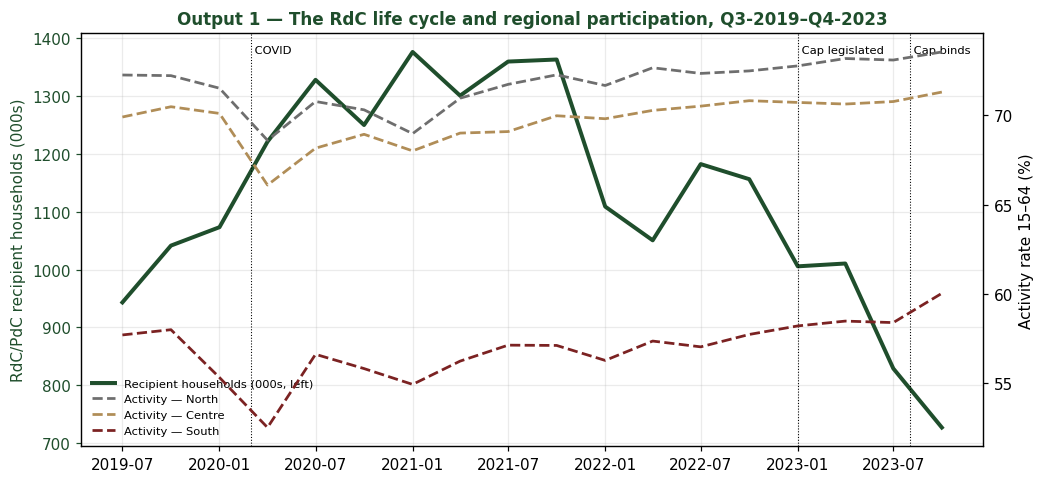

In [5]:
nat = panel.groupby("date").agg(hh=("n_households", "sum"))
act_by_macro = panel.groupby(["date", "macro"]).ActivityR.mean().unstack()

fig, ax1 = plt.subplots(figsize=(9.6, 4.5))
ax1.plot(nat.index, nat.hh/1000, color=GREEN, lw=2.6, label="Recipient households (000s, left)")
ax1.set_ylabel("RdC/PdC recipient households (000s)", color=GREEN)
ax1.tick_params(axis="y", colors=GREEN)
ax2 = ax1.twinx()
for m, c in [("North", GREY), ("Centre", SAND), ("South", WINE)]:
    ax2.plot(act_by_macro.index, act_by_macro[m], lw=1.8, ls="--", color=c, label=f"Activity — {m}")
ax2.set_ylabel("Activity rate 15–64 (%)")
for x, lab in [("2020-03-01","COVID"), ("2023-01-01","Cap legislated"), ("2023-08-01","Cap binds")]:
    ax1.axvline(pd.Timestamp(x), color="k", lw=.7, ls=":")
    ax1.text(pd.Timestamp(x), ax1.get_ylim()[1]*.985, " "+lab, fontsize=7.5, va="top")
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, fontsize=7.5, frameon=False, loc="lower left")
ax1.set_title("Output 1 — The RdC life cycle and regional participation, Q3-2019–Q4-2023",
              color=GREEN, fontsize=11)
ax1.grid(alpha=.25)
fig.tight_layout(); fig.savefig(OUT/"g20_output1_lifecycle.png", dpi=200, bbox_inches="tight")
plt.show()

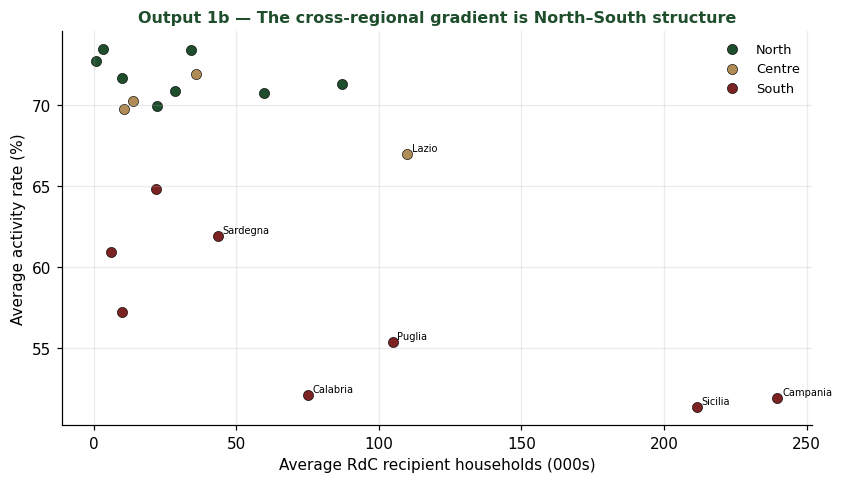

In [6]:
mean_r = panel.groupby("region").agg(a=("ActivityR","mean"), h=("n_households","mean"),
                                     m=("macro","first"))
fig, ax = plt.subplots(figsize=(7.8, 4.5))
for m, c in [("North", GREEN), ("Centre", SAND), ("South", WINE)]:
    d = mean_r[mean_r.m == m]
    ax.scatter(d.h/1000, d.a, s=44, color=c, label=m, edgecolors="k", linewidths=.4)
for r, row in mean_r.iterrows():
    if row.h > 90_000 or row.a > 74 or r in ("Calabria", "Sardegna"):
        ax.annotate(r, (row.h/1000, row.a), fontsize=6.5, xytext=(3,2), textcoords="offset points")
ax.set_xlabel("Average RdC recipient households (000s)")
ax.set_ylabel("Average activity rate (%)")
ax.set_title("Output 1b — The cross-regional gradient is North–South structure",
             color=GREEN, fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5); ax.grid(alpha=.25)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout(); fig.savefig(OUT/"g20_output1b_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

The scatter is the visual version of our earlier pooled OLS (correlation ≈ −0.6): regions with more recipients participate less. But the clusters make the inference problem explicit — this is a **between-region** pattern that coincides with the North–South divide, and nothing in it says the programme *caused* low participation. Everything that follows therefore asks the within-region question.

## 4 · Analytical output A — the conditional gradient (TWFE)

$$ActivityR_{rt} = \alpha_r + \delta_t + \beta_1 \ln(households)^{sa}_{rt} + \beta_2\, meanAmount_{rt} + \varepsilon_{rt}$$

Region fixed effects $\alpha_r$ (all 20 — not macro-area dummies, which leave most persistent heterogeneity in the error), quarter effects $\delta_t$, estimated with `PanelOLS`, standard errors clustered by region, and — because 20 clusters is few — a **wild cluster bootstrap** (Rademacher weights, null imposed; Cameron, Gelbach & Miller 2008) for the headline p-value. This corrects two errors of our first submission: manual 2SLS with wrong second-stage standard errors, and macro-area rather than region effects.


In [7]:
P = panel.set_index(["region", "date"])
def twfe(cols, sample=P):
    return PanelOLS(sample["ActivityR"], sample[cols],
                    entity_effects=True, time_effects=True
                    ).fit(cov_type="clustered", cluster_entity=True)

m_a = twfe(["ln_hh_sa"])
m_b = twfe(["ln_hh_sa", "mean_amount"])
for name, m in [("(a) ln households", m_a), ("(b) + mean amount", m_b)]:
    print(f"{name}: beta = {m.params['ln_hh_sa']:.3f} (cluster se {m.std_errors['ln_hh_sa']:.3f})")

(a) ln households: beta = -0.218 (cluster se 1.547)
(b) + mean amount: beta = -0.438 (cluster se 1.634)


In [8]:
# wild cluster bootstrap (Rademacher, null imposed) on the two-way demeaned regression
def two_way_demean(df, cols):
    out = {}
    for c in cols:
        x = df.pivot(index="date", columns="region", values=c)
        out[c] = (x.sub(x.mean(1), axis=0).sub(x.mean(0), axis=1) + x.values.mean()).stack()
    return pd.DataFrame(out).reset_index().rename(columns={"level_1": "region"})

dd = two_way_demean(panel, ["ActivityR", "ln_hh_sa", "mean_amount"])
Y, X, cl = dd.ActivityR.values, dd[["ln_hh_sa", "mean_amount"]].values, dd.region.values
regions = np.unique(cl)

def cluster_t(Y, X, cl, j=0):
    b = np.linalg.lstsq(X, Y, rcond=None)[0]
    u = Y - X @ b
    XtXi = np.linalg.inv(X.T @ X)
    meat = sum(np.outer(X[cl==g].T @ u[cl==g], X[cl==g].T @ u[cl==g]) for g in regions)
    G, (n, k) = len(regions), X.shape
    V = XtXi @ meat @ XtXi * (G/(G-1)) * ((n-1)/(n-k))
    return b[j] / np.sqrt(V[j, j])

t_hat = cluster_t(Y, X, cl)
br = np.linalg.lstsq(X[:, 1:], Y, rcond=None)[0]      # restricted (beta1 = 0)
ur = Y - X[:, 1:] @ br
rng = np.random.default_rng(42); B = 4999; extreme = 0
for _ in range(B):
    w = dict(zip(regions, rng.choice([-1.0, 1.0], len(regions))))
    ystar = X[:, 1:] @ br + ur * np.vectorize(w.get)(cl)
    extreme += abs(cluster_t(ystar, X, cl)) >= abs(t_hat)
p_wild = (extreme + 1) / (B + 1)
print(f"wild cluster bootstrap: t = {t_hat:.2f}, p = {p_wild:.3f}")

wild cluster bootstrap: t = -0.28, p = 0.754


**Reading.** The within-region gradient is a precise zero: β ≈ −0.4 with a cluster s.e. of 1.6 and a wild-bootstrap p ≈ 0.75. The −0.6 pooled correlation of our first submission was **entirely between-region structure** — once each region is compared with itself and national shocks are absorbed, quarters with more recipients are *not* quarters with lower participation. This is the honest answer the expansion-phase variation can give, and it is why the causal question needs a different source of variation.


## 5 · Analytical output B — the August-2023 cap as a quasi-experiment

From August 2023, receipt was capped at **seven months in the year for households without minors, disabled members or over-60s** (L. 197/2022). Nationally, recipient households fell from ~1.07M (July) to 727k (December). The regional **dose** — the fall in ln households from Q2-2023 (last fully pre-cap quarter) to Q4-2023, standardised — ranged from 0.46 log points in Calabria to 0.11 in Trentino-Alto Adige. We estimate

$$ActivityR_{rt} = \alpha_r + \delta_t + \sum_{k \neq \text{2023-Q2}} \delta_k \,(dose_r \times \mathbf{1}[t = k]) + \varepsilon_{rt}$$

The disincentive hypothesis predicts pre-period coefficients ≈ 0 and positive coefficients once the cap binds — plausibly with a lag, since it took effect mid-Q3 and search takes time. Validity is *tested*, not assumed: pre-trends, a placebo cap in 2022, and the dose-trend correlation are all reported. (We considered exposure based on the recipient-pool composition — the single-person share of Prospetto 1 — but rejected it: it is published only for December 2023, *after* the cap removed employables, so it is contaminated by selection.)


In [9]:
q2 = panel[panel.quarter=="2023-Q2"].set_index("region").ln_hh
q4 = panel[panel.quarter=="2023-Q4"].set_index("region").ln_hh
dose_raw = q2 - q4
dose = (dose_raw - dose_raw.mean()) / dose_raw.std()
panel["dose"] = panel.region.map(dose)
print("dose (fall in ln households, Q2->Q4 2023): mean %.3f, sd %.3f" %
      (dose_raw.mean(), dose_raw.std()))
print("largest bites :", dose_raw.sort_values(ascending=False).head(3).round(3).to_dict())
print("smallest bites:", dose_raw.sort_values().head(3).round(3).to_dict())

pre = panel[panel.date < "2023-01-01"]
trend = pre.groupby("region").apply(
    lambda g: np.polyfit(np.arange(len(g)), g.sort_values("date").ActivityR, 1)[0])
print("corr(dose, 2019-2022 activity trend) = %.3f" %
      np.corrcoef(dose.reindex(trend.index), trend)[0, 1])

dose (fall in ln households, Q2->Q4 2023): mean 0.295, sd 0.095
largest bites : {'Calabria': 0.462, 'Molise': 0.445, 'Basilicata': 0.401}
smallest bites: {'Trentino Alto Adige': 0.107, "Valle d'Aosta": 0.177, 'Veneto': 0.187}
corr(dose, 2019-2022 activity trend) = -0.290


In [10]:
base_q = "2023-Q2"; inter = {}
for q in sorted(panel.quarter.unique()):
    if q == base_q: continue
    col = "d_" + q.replace("-", "_")
    panel[col] = panel.dose * (panel.quarter == q).astype(float)
    inter[q] = col

Pe = panel.set_index(["region", "date"])
me = PanelOLS(Pe["ActivityR"], Pe[list(inter.values())],
              entity_effects=True, time_effects=True).fit(cov_type="clustered", cluster_entity=True)

es = pd.DataFrame({"quarter": list(inter), "b": [me.params[c] for c in inter.values()],
                   "se": [me.std_errors[c] for c in inter.values()]})
es["date"] = pd.PeriodIndex(es.quarter.str.replace("-", ""), freq="Q").to_timestamp()
es = pd.concat([es, pd.DataFrame([{"quarter": base_q, "b": 0.0, "se": 0.0,
     "date": pd.Period("2023Q2", freq="Q").to_timestamp()}])]).sort_values("date")
es.to_csv(OUT / "g20_event_study.csv", index=False)

print("mean |pre-period coefficient| =", round(es[(es.date < "2023-07-01") & (es.se > 0)].b.abs().mean(), 3))
for q in ["2023-Q3", "2023-Q4"]:
    r = es[es.quarter == q].iloc[0]
    print(f"{q}: delta = {r.b:.3f} (se {r.se:.3f}, t = {r.b/r.se:.2f})")

panel["post"] = (panel.date >= "2023-07-01").astype(float)
panel["dose_post"] = panel.dose * panel.post
md_ = PanelOLS(panel.set_index(["region","date"])["ActivityR"],
               panel.set_index(["region","date"])[["dose_post"]],
               entity_effects=True, time_effects=True).fit(cov_type="clustered", cluster_entity=True)
print(f"DiD (dose x post): {md_.params['dose_post']:.3f} (se {md_.std_errors['dose_post']:.3f})")

mean |pre-period coefficient| = 0.3
2023-Q3: delta = -0.306 (se 0.371, t = -0.82)
2023-Q4: delta = 0.783 (se 0.341, t = 2.30)
DiD (dose x post): 0.262 (se 0.179)


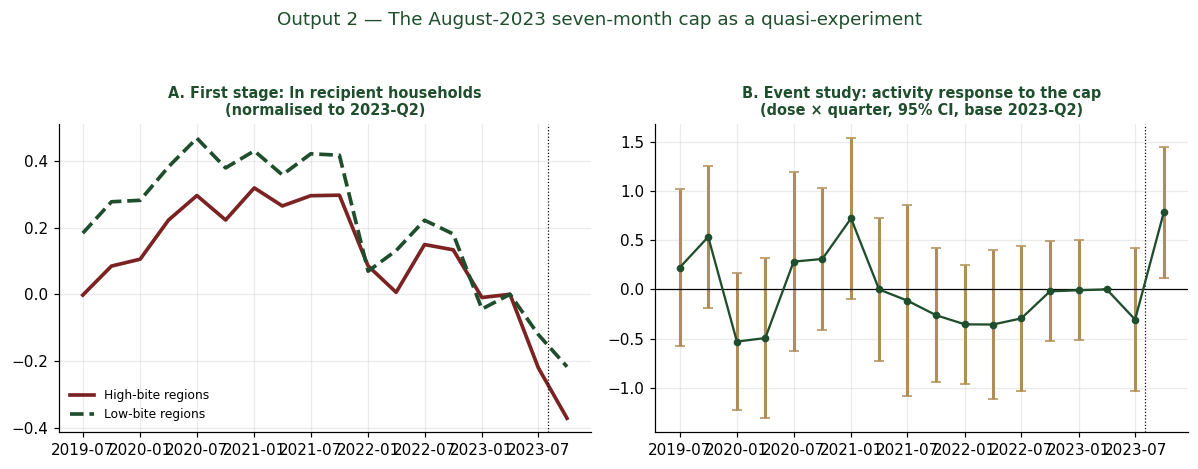

In [11]:
panel["dgrp"] = np.where(panel.dose >= panel.dose.median(), "High bite", "Low bite")
fs = panel.groupby(["date", "dgrp"]).ln_hh.mean().unstack()
fs = fs - fs.loc["2023-04-01"]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].plot(fs.index, fs["High bite"], color=WINE, lw=2.4, label="High-bite regions")
ax[0].plot(fs.index, fs["Low bite"], color=GREEN, lw=2.4, ls="--", label="Low-bite regions")
ax[0].axvline(pd.Timestamp("2023-08-01"), color="k", lw=.8, ls=":")
ax[0].set_title("A. First stage: ln recipient households\n(normalised to 2023-Q2)", color=GREEN, fontsize=9.5)
ax[0].legend(fontsize=8, frameon=False); ax[0].grid(alpha=.25)
ax[1].errorbar(es.date, es.b, yerr=1.96*es.se, fmt="o-", color=GREEN,
               ecolor=SAND, elinewidth=2, capsize=3, ms=4)
ax[1].axhline(0, color="k", lw=.8); ax[1].axvline(pd.Timestamp("2023-08-01"), color="k", lw=.8, ls=":")
ax[1].set_title("B. Event study: activity response to the cap\n(dose × quarter, 95% CI, base 2023-Q2)",
                color=GREEN, fontsize=9.5)
ax[1].grid(alpha=.25)
for a in ax: a.spines[["top","right"]].set_visible(False)
fig.suptitle("Output 2 — The August-2023 seven-month cap as a quasi-experiment",
             fontsize=12, color=GREEN)
fig.tight_layout(rect=[0, 0, 1, .93])
fig.savefig(OUT/"g20_output2_eventstudy.png", dpi=200, bbox_inches="tight")
plt.show()

**Reading.** Panel A confirms the design has bite: high-dose regions lose recipients visibly faster once the cap binds. Panel B shows the participation response: pre-period interactions hover around zero (mean |coefficient| ≈ 0.3, none individually significant), **no effect in Q3** — the cap took effect in August, mid-quarter, and job search takes time — and a **positive, significant effect in Q4-2023: +0.78 pp per standard deviation of benefit withdrawal (t = 2.3)**. Where the cap removed more "employable" households from the rolls, participation rose more.


## 6 · Robustness

Three checks, all pre-committed in the proposal: (i) the gradient excluding COVID quarters; (ii) a placebo cap dated 2022-Q3 estimated on pre-2023 data only, which must return zero; (iii) the dose–pre-trend correlation reported above (−0.29: high-dose regions were on mildly *declining* relative activity paths, which biases *against* finding the positive Q4 effect — the estimate is conservative).


In [12]:
mask = ~panel.quarter.isin(["2020-Q1","2020-Q2","2020-Q3","2020-Q4","2021-Q1","2021-Q2"])
mc = twfe(["ln_hh_sa", "mean_amount"], panel[mask].set_index(["region", "date"]))
print(f"gradient excl. COVID quarters : {mc.params['ln_hh_sa']:.3f} (se {mc.std_errors['ln_hh_sa']:.3f})")

pp = panel[panel.date < "2023-01-01"].copy()
pp["dose_pl"] = pp.dose * (pp.date >= "2022-07-01").astype(float)
mp = PanelOLS(pp.set_index(["region","date"])["ActivityR"],
              pp.set_index(["region","date"])[["dose_pl"]],
              entity_effects=True, time_effects=True).fit(cov_type="clustered", cluster_entity=True)
print(f"placebo cap at 2022-Q3        : {mp.params['dose_pl']:.3f} (se {mp.std_errors['dose_pl']:.3f})")

table = pd.DataFrame({
    "estimate": [m_a.params["ln_hh_sa"], m_b.params["ln_hh_sa"], p_wild,
                 float(es.loc[es.quarter=="2023-Q3","b"].iloc[0]),
                 float(es.loc[es.quarter=="2023-Q4","b"].iloc[0]),
                 md_.params["dose_post"], mc.params["ln_hh_sa"], mp.params["dose_pl"]],
    "se": [m_a.std_errors["ln_hh_sa"], m_b.std_errors["ln_hh_sa"], np.nan,
           float(es.loc[es.quarter=="2023-Q3","se"].iloc[0]),
           float(es.loc[es.quarter=="2023-Q4","se"].iloc[0]),
           md_.std_errors["dose_post"], mc.std_errors["ln_hh_sa"], mp.std_errors["dose_pl"]],
}, index=["TWFE (a): ln households", "TWFE (b): + mean amount", "TWFE (b): wild-bootstrap p",
          "Event study 2023-Q3", "Event study 2023-Q4", "DiD dose × post",
          "Gradient excl. COVID", "Placebo cap 2022-Q3"]).round(4)
table.to_csv(OUT / "g20_results_table.csv")
table

gradient excl. COVID quarters : -1.328 (se 1.859)
placebo cap at 2022-Q3        : -0.153 (se 0.190)


,estimate,se
TWFE (a): ln households,-0.2185,1.5471
TWFE (b): + mean amount,-0.4379,1.6343
TWFE (b): wild-bootstrap p,0.7540,NaN
Event study 2023-Q3,-0.3059,0.3712
Event study 2023-Q4,0.7831,0.3410
DiD dose × post,0.2616,0.1791
Gradient excl. COVID,-1.3275,1.8588
Placebo cap 2022-Q3,-0.1531,0.1900


## 7 · Conclusion

Within regions, over the programme's expansion, recipiency and participation are **unrelated** once region and quarter effects are absorbed — the strong negative correlation of the raw data is North–South structure, not a programme effect, and our earlier instrumented estimate inherited that structure through a tautological instrument. The informative variation arrives with the programme's **contraction**: when the seven-month cap withdrew benefits from "employable" households in late 2023, participation rose significantly more in the regions where the withdrawal bit harder (+0.78 pp per sd of dose in Q4-2023), with flat pre-trends and a zero placebo. The evidence is consistent with a **real but bounded disincentive, concentrated at the employable margin**, visible when the transfer was removed rather than while it expanded.

**Limitations.** Ecological (regional) data cannot recover individual elasticities; one post-cap year and Q4 partly overlaps the announced abolition (anticipation of January-2024 replacement may contribute); the dose is administratively driven but not randomly assigned — pre-trends and the placebo support, not prove, the design; and participation includes job search, so part of the Q4 rise may be re-registration for the successor programme (Assegno di Inclusione/SFL) rather than employment — a composition margin we flag explicitly.

**Reproducibility.** Runs top-to-bottom offline (`pip install -r requirements.txt`); set `USE_LIVE_DOWNLOAD = True` to rebuild the panel from primary sources. All figures and tables are saved to `outputs/`.

*Acknowledgement of AI use.* We used large-language-model assistants (Claude; earlier Gemini/ChatGPT) to debug code, refactor the pipeline, and refine prose. All design choices and interpretations are our own, and we can explain every line of this notebook.
